In [26]:
import numpy as np
import hdbscan
from tslearn.metrics import cdist_dtw
import math
import matplotlib.pyplot as plt
from tslearn.barycenters import dtw_barycenter_averaging
import pandas as pd
from tslearn.metrics import cdist_dtw


In [2]:
data = np.load("D_w50_sample_dtw_float32.npy")

print(data)

[[0.0000000e+00 8.7490873e+00 9.5008020e+00 ... 1.7202106e+01
  1.7201086e+01 1.7201908e+01]
 [8.7490873e+00 0.0000000e+00 1.5318140e+00 ... 1.9919691e+01
  1.9919540e+01 1.9919546e+01]
 [9.5008020e+00 1.5318140e+00 0.0000000e+00 ... 2.0286957e+01
  2.0286848e+01 2.0286812e+01]
 ...
 [1.7202106e+01 1.9919691e+01 2.0286957e+01 ... 0.0000000e+00
  1.8512507e-03 1.0493977e-03]
 [1.7201086e+01 1.9919540e+01 2.0286848e+01 ... 1.8512507e-03
  0.0000000e+00 1.7035307e-03]
 [1.7201908e+01 1.9919546e+01 2.0286812e+01 ... 1.0493977e-03
  1.7035307e-03 0.0000000e+00]]


In [3]:
masyvas = data

In [4]:
masyvas = masyvas.astype(np.float64)
n = masyvas.shape[0]

for min_size in [20, 30, 50, 75, 100]:
    for min_samples in [1, 2, 3, 5, 8, 10, 15]:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_size,
            min_samples=min_samples,
            metric="precomputed",
            cluster_selection_method="eom"   # gali pabandyti ir "eom"
        )
        labels = clusterer.fit_predict(masyvas)
        noise = (labels == -1).sum()
        clusters = len(set(labels)) - (1 if -1 in labels else 0)
        pct = noise / n * 100
        marker = " ✓" if 5 <= pct <= 7 else ""
        print(
            f"min_cluster_size={min_size:4d}, "
            f"min_samples={min_samples:3d} -> "
            f"klasterių: {clusters:3d}, triukšmas: {noise:4d} ({pct:.1f}%){marker}"
        )

min_cluster_size=  20, min_samples=  1 -> klasterių:  24, triukšmas: 2021 (36.3%)
min_cluster_size=  20, min_samples=  2 -> klasterių:  24, triukšmas: 2127 (38.2%)
min_cluster_size=  20, min_samples=  3 -> klasterių:  22, triukšmas: 2242 (40.2%)
min_cluster_size=  20, min_samples=  5 -> klasterių:  22, triukšmas: 2333 (41.9%)
min_cluster_size=  20, min_samples=  8 -> klasterių:  21, triukšmas: 2131 (38.2%)
min_cluster_size=  20, min_samples= 10 -> klasterių:  19, triukšmas: 2185 (39.2%)
min_cluster_size=  20, min_samples= 15 -> klasterių:  16, triukšmas: 2280 (40.9%)
min_cluster_size=  30, min_samples=  1 -> klasterių:  14, triukšmas: 2107 (37.8%)
min_cluster_size=  30, min_samples=  2 -> klasterių:  14, triukšmas: 2203 (39.5%)
min_cluster_size=  30, min_samples=  3 -> klasterių:  14, triukšmas: 2248 (40.3%)
min_cluster_size=  30, min_samples=  5 -> klasterių:  13, triukšmas: 2310 (41.5%)
min_cluster_size=  30, min_samples=  8 -> klasterių:  15, triukšmas: 2097 (37.6%)
min_cluster_size

In [5]:
upper = masyvas[np.triu_indices(n, k=1)]
upper = upper[np.isfinite(upper)]   

q05, q10, q15, q20 = map(float, np.quantile(upper, [0.05, 0.10, 0.15, 0.20]))

eps_values = [0.0, q05, q10, q15, q20]

for eps in eps_values:
    if not np.isfinite(eps) or eps < 0:
        continue

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=20,
        min_samples=1,
        metric="precomputed",
        cluster_selection_method="eom",
        cluster_selection_epsilon=float(eps),
        allow_single_cluster=True
    )

    labels = clusterer.fit_predict(masyvas)
    noise = (labels == -1).sum()
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    pct = noise / n * 100

    print(f"eps={eps:.6f} -> klasterių: {clusters:3d}, triukšmas: {noise:4d} ({pct:.1f}%)")

eps=0.000000 -> klasterių:  24, triukšmas: 2021 (36.3%)
eps=8.348676 -> klasterių:   1, triukšmas:  199 (3.6%)
eps=11.034992 -> klasterių:   1, triukšmas:   74 (1.3%)
eps=12.979930 -> klasterių:   1, triukšmas:   40 (0.7%)
eps=14.573988 -> klasterių:   1, triukšmas:   29 (0.5%)


In [6]:
upper = masyvas[np.triu_indices(masyvas.shape[0], k=1)]
upper = upper[np.isfinite(upper)]

q001, q002, q005, q01, q02 = map(float, np.quantile(upper, [0.001, 0.002, 0.005, 0.01, 0.02]))

for eps in [0.0, q001, q002, q005, q01, q02]:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=20,
        min_samples=1,
        metric="precomputed",
        cluster_selection_method="eom",
        cluster_selection_epsilon=float(eps),
        allow_single_cluster=False
    )
    labels = clusterer.fit_predict(masyvas)
    noise = (labels == -1).sum()
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    pct = noise / masyvas.shape[0] * 100
    print(f"eps={eps:.6f} -> klasterių: {clusters:3d}, triukšmas: {noise:4d} ({pct:.1f}%)")

eps=0.000000 -> klasterių:  24, triukšmas: 2021 (36.3%)
eps=0.889796 -> klasterių:   9, triukšmas: 1926 (34.6%)
eps=1.556847 -> klasterių:   5, triukšmas: 1690 (30.3%)
eps=2.632962 -> klasterių:   5, triukšmas: 1690 (30.3%)
eps=3.753544 -> klasterių:   2, triukšmas:  496 (8.9%)
eps=5.380181 -> klasterių:   2, triukšmas:  496 (8.9%)


In [7]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=1,
    metric="precomputed",
    cluster_selection_method="eom",
    cluster_selection_epsilon=0.0
)

labels = clusterer.fit_predict(masyvas)

original_labels = labels.copy()
original_noise_mask = (original_labels == -1)

final_labels = labels.copy()

cluster_ids = sorted(set(labels) - {-1})
noise_idx = np.where(labels == -1)[0]

for i in noise_idx:
    best_cluster = None
    best_dist = np.inf
    
    for c in cluster_ids:
        members = np.where(labels == c)[0]
        if len(members) == 0:
            continue
        
        avg_dist = masyvas[i, members].mean()
        
        if avg_dist < best_dist:
            best_dist = avg_dist
            best_cluster = c
    
    final_labels[i] = best_cluster

orig_noise = (original_labels == -1).sum()
final_noise = (final_labels == -1).sum()
orig_clusters = len(set(original_labels)) - (1 if -1 in original_labels else 0)
final_clusters = len(set(final_labels)) - (1 if -1 in final_labels else 0)

print(f"Original HDBSCAN -> klasterių: {orig_clusters}, triukšmas: {orig_noise} ({orig_noise / len(labels) * 100:.1f}%)")
print(f"Po priskyrimo    -> klasterių: {final_clusters}, triukšmas: {final_noise} ({final_noise / len(labels) * 100:.1f}%)")

Original HDBSCAN -> klasterių: 24, triukšmas: 2021 (36.3%)
Po priskyrimo    -> klasterių: 24, triukšmas: 0 (0.0%)


In [29]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=1,
    metric="precomputed",
    cluster_selection_method="eom",
    cluster_selection_epsilon=0.0
)

labels_hdbscan = clusterer.fit_predict(masyvas)

original_labels = labels_hdbscan.copy()
final_labels = labels_hdbscan.copy()

n = len(final_labels)

n_noise = np.sum(final_labels == -1)
n_clusters = len(set(final_labels) - {-1})

print(f"HDBSCAN klasterių: {n_clusters}")
print(f"HDBSCAN noise: {n_noise} ({n_noise / n * 100:.1f}%)")

HDBSCAN klasterių: 24
HDBSCAN noise: 2021 (36.3%)


In [30]:
clusters, counts = np.unique(final_labels, return_counts=True)

for c, cnt in zip(clusters, counts):
    print(f"Klasteris {int(c):3d}: {cnt:4d} stebėjimų")

Klasteris  -1: 2021 stebėjimų
Klasteris   0:   25 stebėjimų
Klasteris   1: 2673 stebėjimų
Klasteris   2:   29 stebėjimų
Klasteris   3:   24 stebėjimų
Klasteris   4:   33 stebėjimų
Klasteris   5:   38 stebėjimų
Klasteris   6:   43 stebėjimų
Klasteris   7:   22 stebėjimų
Klasteris   8:   27 stebėjimų
Klasteris   9:   91 stebėjimų
Klasteris  10:   56 stebėjimų
Klasteris  11:   34 stebėjimų
Klasteris  12:  103 stebėjimų
Klasteris  13:   36 stebėjimų
Klasteris  14:   22 stebėjimų
Klasteris  15:   33 stebėjimų
Klasteris  16:   26 stebėjimų
Klasteris  17:   40 stebėjimų
Klasteris  18:   48 stebėjimų
Klasteris  19:   20 stebėjimų
Klasteris  20:   26 stebėjimų
Klasteris  21:   46 stebėjimų
Klasteris  22:   30 stebėjimų
Klasteris  23:   26 stebėjimų


In [31]:
cluster_reps = {}

for c in sorted(set(final_labels) - {-1}):
    members = np.where(final_labels == c)[0]
    
    if len(members) <= 3:
        cluster_reps[c] = members.tolist()
        continue
    
    D = masyvas[np.ix_(members, members)]
    sums = D.sum(axis=1)
    
    medoid_pos = np.argmin(sums)
    medoid_idx = members[medoid_pos]
    
    order = np.argsort(D[medoid_pos])
    nearest_local = [members[i] for i in order if members[i] != medoid_idx]
    
    reps = [medoid_idx] + nearest_local[:2]
    cluster_reps[c] = reps

print("Klasterių su reprezentantais:", len(cluster_reps))
print("Reprezentantų kiekis:", sum(len(v) for v in cluster_reps.values()))

Klasterių su reprezentantais: 24
Reprezentantų kiekis: 72


In [32]:
train_best_dists = []

for i in range(len(final_labels)):
    c = final_labels[i]
    
    if c == -1:
        continue
    
    reps = cluster_reps[c]
    dists = [masyvas[i, r] for r in reps]
    train_best_dists.append(min(dists))

train_best_dists = np.array(train_best_dists)

threshold = float(np.quantile(train_best_dists, 0.80))

print("Threshold skaičiuotas iš:", len(train_best_dists), "ne-noise sample sekų")
print("Naudojamas slenkstis:", threshold)

Threshold skaičiuotas iš: 3551 ne-noise sample sekų
Naudojamas slenkstis: 27.948205947875977


In [33]:
new_sequences = np.load("X_w50_remaining.npy", allow_pickle=False)
subset_sequences = np.load("X_w50_sample.npy", allow_pickle=False)

print("new_sequences:", new_sequences.shape, new_sequences.dtype)
print("subset_sequences:", subset_sequences.shape, subset_sequences.dtype)

new_sequences: (49860, 50, 6) float32
subset_sequences: (5572, 50, 6) float32


In [35]:
rep_indices = []
rep_clusters = []

for c, reps in cluster_reps.items():
    if c == -1:
        continue

    for r in reps:
        rep_indices.append(r)
        rep_clusters.append(c)

rep_indices = np.array(rep_indices)
rep_clusters = np.array(rep_clusters)

representative_sequences = subset_sequences[rep_indices].astype(np.float64)

print("Reprezentantų kiekis:", len(representative_sequences))
print("Naujų sekų kiekis:", len(new_sequences))
print("Iš viso DTW atstumų:", len(new_sequences) * len(representative_sequences))

Reprezentantų kiekis: 72
Naujų sekų kiekis: 49860
Iš viso DTW atstumų: 3589920


In [36]:
assigned_labels = []
assigned_dists = []

chunk_size = 500

for start in range(0, len(new_sequences), chunk_size):
    end = min(start + chunk_size, len(new_sequences))

    chunk = new_sequences[start:end].astype(np.float64)

    D_chunk = cdist_dtw(
        chunk,
        representative_sequences,
        n_jobs=-1
    )

    best_rep_pos = np.argmin(D_chunk, axis=1)
    best_dists = D_chunk[np.arange(len(chunk)), best_rep_pos]
    best_clusters = rep_clusters[best_rep_pos]

    labels_chunk = np.where(best_dists <= threshold, best_clusters, -1)

    assigned_labels.extend(labels_chunk)
    assigned_dists.extend(best_dists)

    print(f"Baigta: {end}/{len(new_sequences)}")

assigned_labels = np.array(assigned_labels)
assigned_dists = np.array(assigned_dists)

print("Triukšmas:", np.sum(assigned_labels == -1))
print("Triukšmo procentas:", np.mean(assigned_labels == -1) * 100)

Baigta: 500/49860
Baigta: 1000/49860
Baigta: 1500/49860
Baigta: 2000/49860
Baigta: 2500/49860
Baigta: 3000/49860
Baigta: 3500/49860
Baigta: 4000/49860
Baigta: 4500/49860
Baigta: 5000/49860
Baigta: 5500/49860
Baigta: 6000/49860
Baigta: 6500/49860
Baigta: 7000/49860
Baigta: 7500/49860
Baigta: 8000/49860
Baigta: 8500/49860
Baigta: 9000/49860
Baigta: 9500/49860
Baigta: 10000/49860
Baigta: 10500/49860
Baigta: 11000/49860
Baigta: 11500/49860
Baigta: 12000/49860
Baigta: 12500/49860
Baigta: 13000/49860
Baigta: 13500/49860
Baigta: 14000/49860
Baigta: 14500/49860
Baigta: 15000/49860
Baigta: 15500/49860
Baigta: 16000/49860
Baigta: 16500/49860
Baigta: 17000/49860
Baigta: 17500/49860
Baigta: 18000/49860
Baigta: 18500/49860
Baigta: 19000/49860
Baigta: 19500/49860
Baigta: 20000/49860
Baigta: 20500/49860
Baigta: 21000/49860
Baigta: 21500/49860
Baigta: 22000/49860
Baigta: 22500/49860
Baigta: 23000/49860
Baigta: 23500/49860
Baigta: 24000/49860
Baigta: 24500/49860
Baigta: 25000/49860
Baigta: 25500/49860


In [37]:
percentiles = [60, 65, 70, 75, 80, 85, 90, 95]

thresholds = {
    p: float(np.percentile(train_best_dists, p))
    for p in percentiles
}

print("Slenksčiai pagal mokymo poaibio atstumus iki klasterio reprezentantų:")

for p, value in thresholds.items():
    print(f"{p}-asis procentilis: {value:.4f}")

Slenksčiai pagal mokymo poaibio atstumus iki klasterio reprezentantų:
60-asis procentilis: 18.1285
65-asis procentilis: 22.7172
70-asis procentilis: 25.2675
75-asis procentilis: 26.6401
80-asis procentilis: 27.9482
85-asis procentilis: 28.9529
90-asis procentilis: 30.0449
95-asis procentilis: 31.3479


In [38]:
sample_noise = np.sum(np.array(final_labels) == -1)
sample_size = len(final_labels)
remaining_size = len(assigned_dists)

sensitivity_rows = []

for p, threshold_value in thresholds.items():
    remaining_noise = np.sum(assigned_dists > threshold_value)
    remaining_assigned = remaining_size - remaining_noise
    
    total_noise = sample_noise + remaining_noise
    total_size = sample_size + remaining_size
    
    sensitivity_rows.append({
        "Procentilis": p,
        "Slenkstis": threshold_value,
        "Priskirtos naujos sekos": remaining_assigned,
        "Triukšmas naujose sekose": remaining_noise,
        "Triukšmas naujose sekose, %": remaining_noise / remaining_size * 100,
        "Bendras triukšmas": total_noise,
        "Bendras triukšmas, %": total_noise / total_size * 100
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)

display(sensitivity_df)

,Procentilis,Slenkstis,Priskirtos naujos sekos,Triukšmas naujose sekose,"Triukšmas naujose sekose, %",Bendras triukšmas,"Bendras triukšmas, %"
0,60,18.128504,39973,9887,19.829523,11908,21.482176
1,65,22.717215,47124,2736,5.487365,4757,8.581686
2,70,25.267458,48331,1529,3.066586,3550,6.404243
3,75,26.640134,48770,1090,2.186121,3111,5.612282
4,80,27.948206,49104,756,1.516245,2777,5.009742
5,85,28.952863,49275,585,1.173285,2606,4.701256
6,90,30.044941,49437,423,0.848375,2444,4.409006
7,95,31.347869,49574,286,0.573606,2307,4.161856


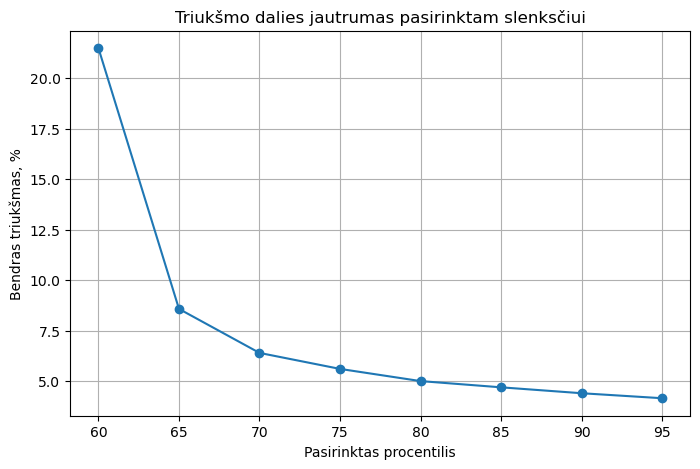

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    sensitivity_df["Procentilis"],
    sensitivity_df["Bendras triukšmas, %"],
    marker="o"
)

plt.xlabel("Pasirinktas procentilis")
plt.ylabel("Bendras triukšmas, %")
plt.title("Triukšmo dalies jautrumas pasirinktam slenksčiui")
plt.grid(True)
plt.show()

In [40]:
assigned_labels_80 = []
assigned_dists_80 = []
assigned_best_clusters_80 = []

chunk_size = 500
threshold_80 = float(np.quantile(train_best_dists, 0.80))
for start in range(0, len(new_sequences), chunk_size):
    end = min(start + chunk_size, len(new_sequences))

    chunk = new_sequences[start:end].astype(np.float64)

    D_chunk = cdist_dtw(
        chunk,
        representative_sequences,
        n_jobs=-1
    )

    best_rep_pos = np.argmin(D_chunk, axis=1)
    best_dists = D_chunk[np.arange(len(chunk)), best_rep_pos]
    best_clusters = rep_clusters[best_rep_pos]

    labels_chunk = np.where(best_dists <= threshold_80, best_clusters, -1)

    assigned_labels_80.extend(labels_chunk)
    assigned_dists_80.extend(best_dists)
    assigned_best_clusters_80.extend(best_clusters)

    print(f"Baigta: {end}/{len(new_sequences)}")

assigned_labels_80 = np.array(assigned_labels_80)
assigned_dists_80 = np.array(assigned_dists_80)
assigned_best_clusters_80 = np.array(assigned_best_clusters_80)

print("Triukšmas su 80 %:", np.sum(assigned_labels_80 == -1))
print("Triukšmo procentas su 80 %:", np.mean(assigned_labels_80 == -1) * 100)

Baigta: 500/49860
Baigta: 1000/49860
Baigta: 1500/49860
Baigta: 2000/49860
Baigta: 2500/49860
Baigta: 3000/49860
Baigta: 3500/49860
Baigta: 4000/49860
Baigta: 4500/49860
Baigta: 5000/49860
Baigta: 5500/49860
Baigta: 6000/49860
Baigta: 6500/49860
Baigta: 7000/49860
Baigta: 7500/49860
Baigta: 8000/49860
Baigta: 8500/49860
Baigta: 9000/49860
Baigta: 9500/49860
Baigta: 10000/49860
Baigta: 10500/49860
Baigta: 11000/49860
Baigta: 11500/49860
Baigta: 12000/49860
Baigta: 12500/49860
Baigta: 13000/49860
Baigta: 13500/49860
Baigta: 14000/49860
Baigta: 14500/49860
Baigta: 15000/49860
Baigta: 15500/49860
Baigta: 16000/49860
Baigta: 16500/49860
Baigta: 17000/49860
Baigta: 17500/49860
Baigta: 18000/49860
Baigta: 18500/49860
Baigta: 19000/49860
Baigta: 19500/49860
Baigta: 20000/49860
Baigta: 20500/49860
Baigta: 21000/49860
Baigta: 21500/49860
Baigta: 22000/49860
Baigta: 22500/49860
Baigta: 23000/49860
Baigta: 23500/49860
Baigta: 24000/49860
Baigta: 24500/49860
Baigta: 25000/49860
Baigta: 25500/49860


In [41]:
X_original = np.load("X_w50_original.npy", allow_pickle=False)
sample_idx = np.load("sample_idx_w50.npy", allow_pickle=False)

all_idx = np.arange(len(X_original))
remaining_idx = np.setdiff1d(all_idx, sample_idx)

sample_meta = pd.read_csv("metadata_w50_sample.csv").reset_index(drop=True)
remaining_meta = pd.read_csv("metadata_w50_remaining.csv").reset_index(drop=True)

labels_all_80 = np.full(len(X_original), -999, dtype=int)
labels_all_80[sample_idx] = np.array(final_labels)
labels_all_80[remaining_idx] = np.array(assigned_labels_80)

sample_part_80 = sample_meta.copy()
sample_part_80["global_idx"] = sample_idx
sample_part_80["source"] = "sample"
sample_part_80["hdbscan_cluster"] = labels_all_80[sample_idx]

remaining_part_80 = remaining_meta.copy()
remaining_part_80["global_idx"] = remaining_idx
remaining_part_80["source"] = "remaining"
remaining_part_80["hdbscan_cluster"] = labels_all_80[remaining_idx]

full_hdbscan_meta_80 = pd.concat(
    [sample_part_80, remaining_part_80],
    ignore_index=True
)

full_hdbscan_meta_80 = (
    full_hdbscan_meta_80
    .sort_values("global_idx")
    .reset_index(drop=True)
)

print("Visų sekų kiekis:", len(full_hdbscan_meta_80))
print("Triukšmo sekų kiekis:", np.sum(labels_all_80 == -1))
print("Triukšmo procentas:", round(np.mean(labels_all_80 == -1) * 100, 2))

display(full_hdbscan_meta_80.head())

Visų sekų kiekis: 55432
Triukšmo sekų kiekis: 2777
Triukšmo procentas: 5.01


,sequence_id,mmsi,block_id,start_time,end_time,window_start_idx,window_end_idx,center_x,center_y,x_bin,y_bin,stratum,is_forced_vessel,global_idx,source,hdbscan_cluster
0,0,205136000,1,2025-05-16 21:26:00,2025-05-16 23:04:00,0,49,NaN,NaN,NaN,NaN,NaN,NaN,0,remaining,1
1,1,205136000,1,2025-05-16 22:16:00,2025-05-16 23:54:00,25,74,NaN,NaN,NaN,NaN,NaN,NaN,1,remaining,1
2,2,205136000,1,2025-05-16 23:06:00,2025-05-17 00:44:00,50,99,NaN,NaN,NaN,NaN,NaN,NaN,2,remaining,1
3,3,205136000,1,2025-05-16 23:56:00,2025-05-17 01:34:00,75,124,NaN,NaN,NaN,NaN,NaN,NaN,3,remaining,1
4,4,205136000,1,2025-05-17 00:46:00,2025-05-17 02:24:00,100,149,NaN,NaN,NaN,NaN,NaN,NaN,4,remaining,1


In [42]:
X_sample_scaled = np.load("X_w50_sample.npy", allow_pickle=False)
X_remaining_scaled = np.load("X_w50_remaining.npy", allow_pickle=False)

labels_sample_80 = np.array(final_labels)
labels_remaining_80 = np.array(assigned_labels_80)

sample_noise_mask_80 = labels_sample_80 == -1
remaining_noise_mask_80 = labels_remaining_80 == -1

X_noise_sample_80 = X_sample_scaled[sample_noise_mask_80]
X_noise_remaining_80 = X_remaining_scaled[remaining_noise_mask_80]

X_noise_80 = np.concatenate(
    [X_noise_sample_80, X_noise_remaining_80],
    axis=0
)

sample_noise_meta_80 = sample_meta[sample_noise_mask_80].copy()
sample_noise_meta_80["source"] = "sample"
sample_noise_meta_80["source_row"] = np.where(sample_noise_mask_80)[0]
sample_noise_meta_80["global_idx"] = sample_idx[sample_noise_mask_80]
sample_noise_meta_80["hdbscan_cluster"] = -1

remaining_noise_meta_80 = remaining_meta[remaining_noise_mask_80].copy()
remaining_noise_meta_80["source"] = "remaining"
remaining_noise_meta_80["source_row"] = np.where(remaining_noise_mask_80)[0]
remaining_noise_meta_80["global_idx"] = remaining_idx[remaining_noise_mask_80]
remaining_noise_meta_80["hdbscan_cluster"] = -1

noise_meta_80 = pd.concat(
    [sample_noise_meta_80, remaining_noise_meta_80],
    ignore_index=True
)

noise_meta_80.insert(0, "noise_row", np.arange(len(noise_meta_80)))

print("X_noise_80 shape:", X_noise_80.shape)
print("noise_meta_80 shape:", noise_meta_80.shape)

print("\nTriukšmai pagal šaltinį:")
display(noise_meta_80["source"].value_counts().reset_index())

display(noise_meta_80.head())

X_noise_80 shape: (2777, 50, 6)
noise_meta_80 shape: (2777, 18)

Triukšmai pagal šaltinį:


,source,count
0,sample,2021
1,remaining,756


,noise_row,sequence_id,mmsi,block_id,start_time,end_time,window_start_idx,window_end_idx,center_x,center_y,x_bin,y_bin,stratum,is_forced_vessel,source,source_row,global_idx,hdbscan_cluster
0,0,41,205136000,1,2025-05-18 07:36:00,2025-05-18 09:14:00,1025,1074,-0.188086,0.772847,5.0,16.0,5_16,False,sample,3,41,-1
1,1,43,205136000,1,2025-05-18 09:16:00,2025-05-18 10:54:00,1075,1124,0.021511,0.223109,13.0,14.0,13_14,False,sample,4,43,-1
2,2,56,205136000,1,2025-05-18 20:06:00,2025-05-18 21:44:00,1400,1449,-0.018383,-0.007411,10.0,9.0,10_9,False,sample,5,56,-1
3,3,57,205136000,1,2025-05-18 20:56:00,2025-05-18 22:34:00,1425,1474,-0.018483,-0.007417,8.0,9.0,8_9,False,sample,6,57,-1
4,4,218,209056000,1,2025-05-17 01:10:00,2025-05-17 02:48:00,1025,1074,-0.545903,-0.335964,4.0,5.0,4_5,False,sample,27,218,-1


In [43]:
np.save("full_hdbscan_labels_all_80.npy", labels_all_80)

full_hdbscan_meta_80.to_csv(
    "full_hdbscan_metadata_80.csv",
    index=False
)

np.save("triuksmai_80.npy", X_noise_80)

noise_meta_80.to_csv(
    "triuksmai_metadata_80.csv",
    index=False
)

np.save(
    "triuksmai_global_idx_80.npy",
    noise_meta_80["global_idx"].to_numpy()
)

print("Išsaugota:")
print("full_hdbscan_labels_all_80.npy")
print("full_hdbscan_metadata_80.csv")
print("triuksmai_80.npy")
print("triuksmai_metadata_80.csv")
print("triuksmai_global_idx_80.npy")

Išsaugota:
full_hdbscan_labels_all_80.npy
full_hdbscan_metadata_80.csv
triuksmai_80.npy
triuksmai_metadata_80.csv
triuksmai_global_idx_80.npy


In [ ]:
X_noise_80_for_dtw = X_noise_80.astype(np.float64)

n_noise_80 = len(X_noise_80_for_dtw)

D_noise_80 = np.zeros(
    (n_noise_80, n_noise_80),
    dtype=np.float32
)

chunk_size = 250

for start in range(0, n_noise_80, chunk_size):
    end = min(start + chunk_size, n_noise_80)

    D_chunk = cdist_dtw(
        X_noise_80_for_dtw[start:end],
        X_noise_80_for_dtw,
        n_jobs=-1
    )

    D_noise_80[start:end] = D_chunk.astype(np.float32)

    print(f"Baigta: {end}/{n_noise_80}")

np.fill_diagonal(D_noise_80, 0.0)

np.save("D_triuksmai_80_dtw_float32.npy", D_noise_80)

print("Išsaugota D_triuksmai_80_dtw_float32.npy")
print("Shape:", D_noise_80.shape)
print("Dtype:", D_noise_80.dtype)

Sample trajektorijų: 5572
Remaining trajektorijų: 49860
Iš viso trajektorijų: 55432
Labelių kiekis: 55432


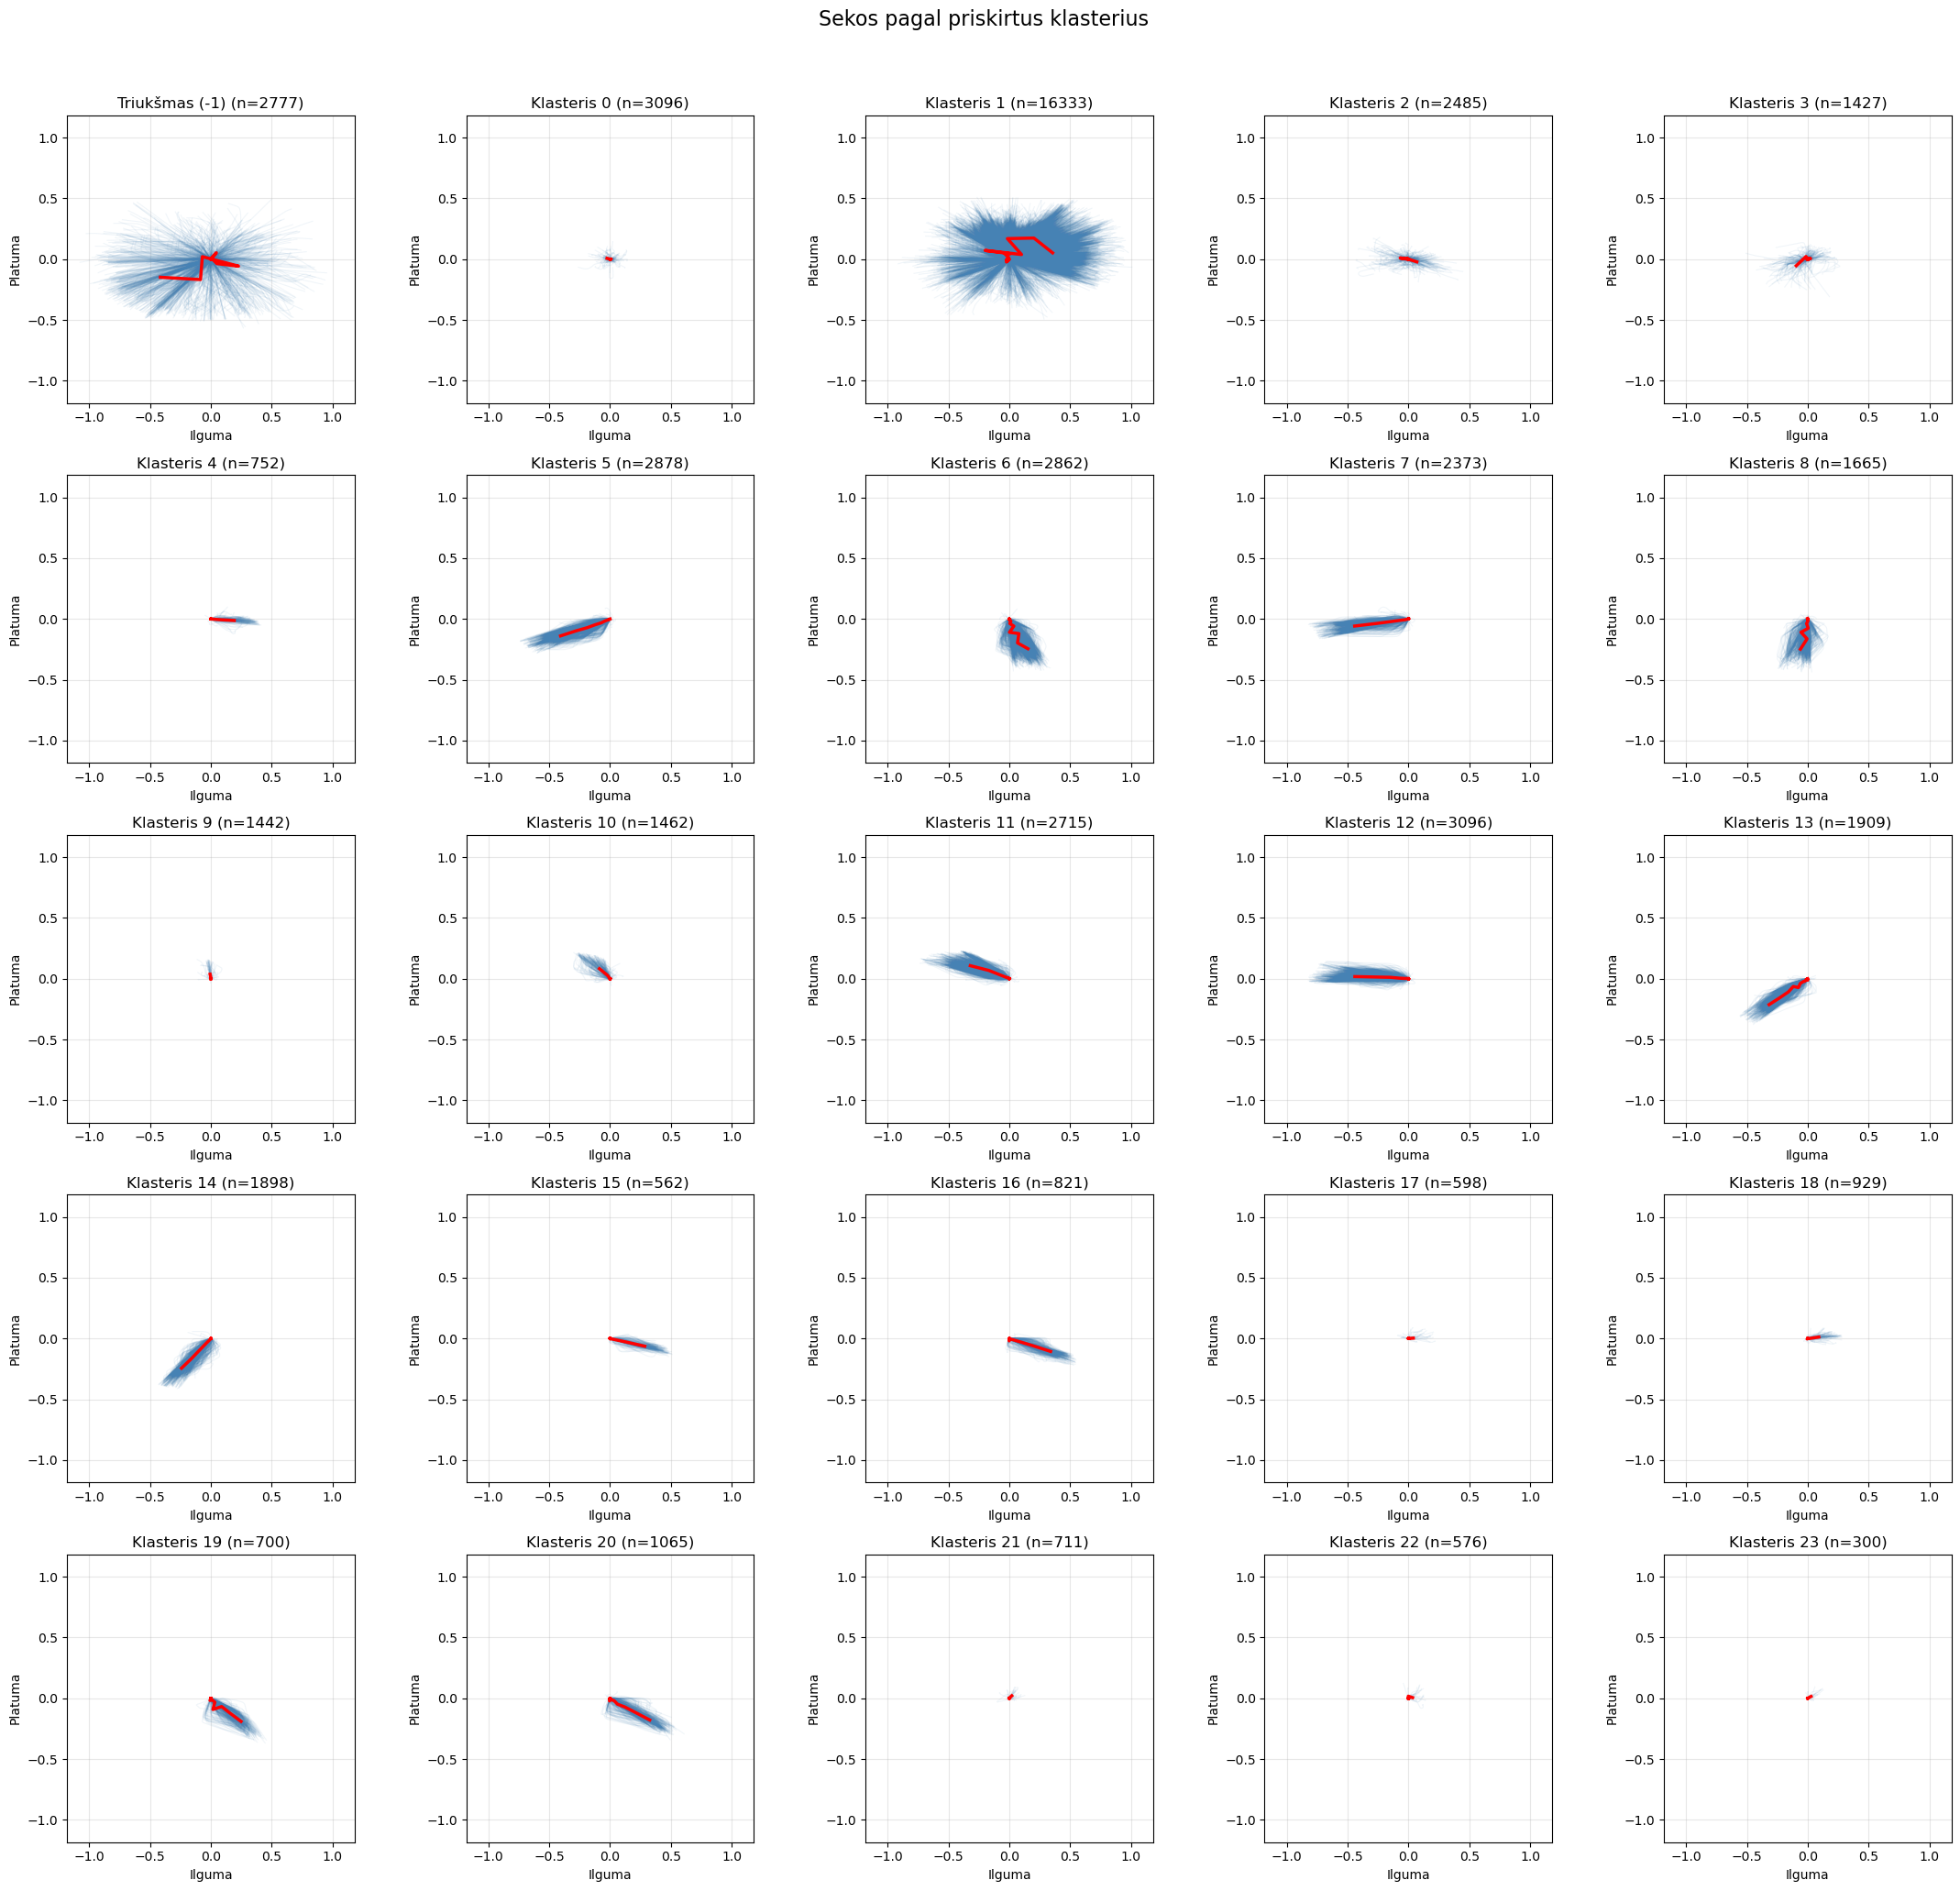

In [45]:
X_raw = np.load("X_w50_raw.npy", allow_pickle=False)
sample_idx = np.load("sample_idx_w50.npy", allow_pickle=False)

all_idx = np.arange(len(X_raw))
remaining_idx = np.setdiff1d(all_idx, sample_idx)

X_sample = X_raw[sample_idx].astype(np.float64)
labels_sample = np.array(final_labels)

X_remaining = X_raw[remaining_idx].astype(np.float64)
labels_remaining = np.array(assigned_labels_80)

if len(X_sample) != len(labels_sample):
    raise ValueError("KLAIDA: X_sample ir labels_sample ilgiai nesutampa.")

if len(X_remaining) != len(labels_remaining):
    raise ValueError("KLAIDA: X_remaining ir labels_remaining ilgiai nesutampa.")

X_80 = np.concatenate([X_sample, X_remaining], axis=0)
labels_80 = np.concatenate([labels_sample, labels_remaining], axis=0)

print("Sample trajektorijų:", len(X_sample))
print("Remaining trajektorijų:", len(X_remaining))
print("Iš viso trajektorijų:", len(X_80))
print("Labelių kiekis:", len(labels_80))

all_y_global = X_80[:, :, 0].ravel()
all_x_global = X_80[:, :, 1].ravel()

valid_global = np.isfinite(all_x_global) & np.isfinite(all_y_global)

all_x_global = all_x_global[valid_global]
all_y_global = all_y_global[valid_global]

xmin, xmax = np.min(all_x_global), np.max(all_x_global)
ymin, ymax = np.min(all_y_global), np.max(all_y_global)

max_abs = max(abs(xmin), abs(xmax), abs(ymin), abs(ymax))
pad = max(max_abs * 0.1, 0.001)

xlim_global = (-max_abs - pad, max_abs + pad)
ylim_global = (-max_abs - pad, max_abs + pad)

unique_clusters = sorted(np.unique(labels_80))

n_clusters = len(unique_clusters)
n_cols = 5
n_rows = math.ceil(n_clusters / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(22, 4.2 * n_rows),
    sharex=False,
    sharey=False
)

axes = np.array(axes).reshape(-1)

rng = np.random.default_rng(42)

for plot_i, k in enumerate(unique_clusters):
    ax = axes[plot_i]

    idx = np.where(labels_80 == k)[0]

    for i in idx:
        coords = X_80[i]

        y = coords[:, 0]
        x = coords[:, 1]

        valid = np.isfinite(x) & np.isfinite(y)

        if valid.any():
            ax.plot(
                x[valid],
                y[valid],
                color="steelblue",
                alpha=0.08,
                linewidth=0.8
            )

    if len(idx) > 0:
        if len(idx) > 200:
            idx_for_bary = rng.choice(idx, size=200, replace=False)
        else:
            idx_for_bary = idx

        cluster_series = X_80[idx_for_bary, :, :2]

        barycenter = dtw_barycenter_averaging(
            cluster_series,
            max_iter=20
        )

        valid_bary = (
            np.isfinite(barycenter[:, 0])
            & np.isfinite(barycenter[:, 1])
        )

        ax.plot(
            barycenter[valid_bary, 1],
            barycenter[valid_bary, 0],
            color="red",
            linewidth=2.5
        )

    ax.set_xlim(xlim_global)
    ax.set_ylim(ylim_global)

    title_name = "Triukšmas (-1)" if k == -1 else f"Klasteris {k}"
    ax.set_title(f"{title_name} (n={len(idx)})")

    ax.set_xlabel("Ilguma")
    ax.set_ylabel("Platuma")

    ax.tick_params(
        axis="both",
        which="both",
        bottom=True,
        top=False,
        left=True,
        right=False,
        labelbottom=True,
        labelleft=True
    )

    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Sekos pagal priskirtus klasterius",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()